# Social Media Toxicity Classifier

**Problem:** Online platforms struggle to moderate toxic content at scale. A single moderator cannot review millions of comments daily. This project builds an automated two-stage classifier that detects whether a comment is toxic, and if so, identifies *what type* of toxicity — enabling platforms to prioritize and act faster.


## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import emoji
import warnings
warnings.filterwarnings('ignore')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,f1_score, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE

import joblib

## 2. Load & Understand Dataset

In [3]:
df = pd.read_csv('train.csv')
print("Shape:", df.shape)
df.head()

Shape: (159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id             159571 non-null  str  
 1   comment_text   159571 non-null  str  
 2   toxic          159571 non-null  int64
 3   severe_toxic   159571 non-null  int64
 4   obscene        159571 non-null  int64
 5   threat         159571 non-null  int64
 6   insult         159571 non-null  int64
 7   identity_hate  159571 non-null  int64
dtypes: int64(6), str(2)
memory usage: 72.2 MB


In [5]:
# Check for nulls and duplicates
print("Null values:\n", df.isnull().sum())
print("\nDuplicated rows:", df.duplicated().sum())

Null values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Duplicated rows: 0


## 3. Exploratory Data Analysis


### 3.1 Class Imbalance Check

In [6]:
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Clean vs toxic split
df['is_toxic'] = (df[label_cols].sum(axis=1) > 0).astype(int)
toxic_counts = df['is_toxic'].value_counts()

print("Clean comments :", toxic_counts[0], f"({toxic_counts[0]/len(df)*100:.1f}%)")
print("Toxic comments :", toxic_counts[1], f"({toxic_counts[1]/len(df)*100:.1f}%)")


Clean comments : 143346 (89.8%)
Toxic comments : 16225 (10.2%)


### 3.2 Label Distribution

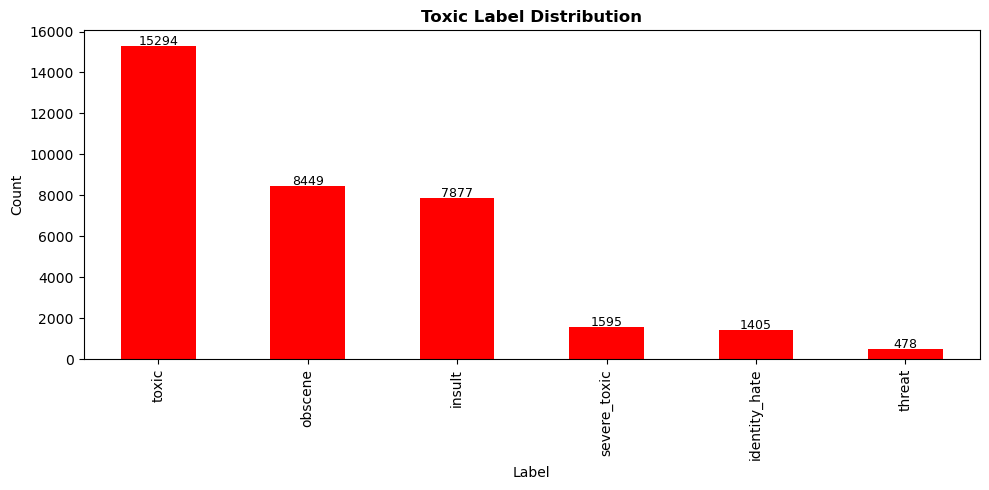

In [10]:
label_counts = df[label_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = label_counts.plot(kind='bar', color='red')
plt.title("Toxic Label Distribution",fontweight='bold')
plt.xlabel("Label")
plt.ylabel("Count")

for i, v in enumerate(label_counts):
    plt.text(i, v + 50, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### 3.3 Label Co-occurrence (Do toxic types overlap?)

In [11]:
# How many labels does each toxic comment have?
df['num_labels'] = df[label_cols].sum(axis=1)
label_dist = df['num_labels'].value_counts().sort_index()

print("Number of labels per comment:")
for k, v in label_dist.items():
    print(f"  {k} labels: {v:,} comments")


Number of labels per comment:
  0 labels: 143,346 comments
  1 labels: 6,360 comments
  2 labels: 3,480 comments
  3 labels: 4,209 comments
  4 labels: 1,760 comments
  5 labels: 385 comments
  6 labels: 31 comments


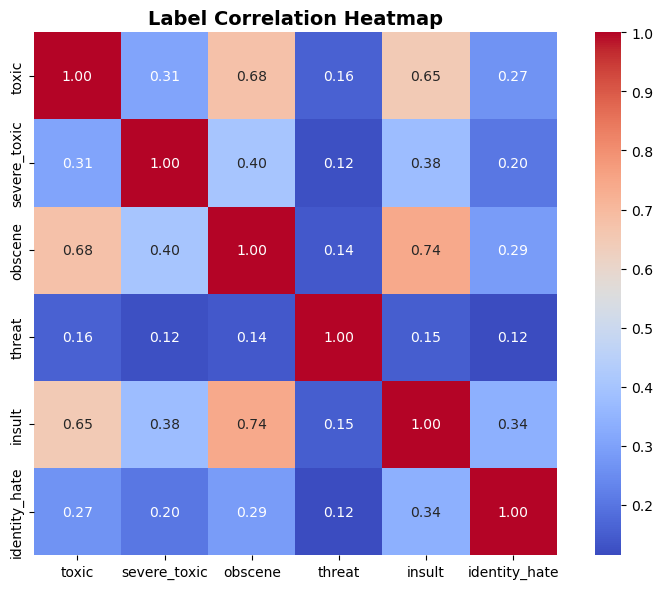

In [12]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df[label_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title("Label Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



### 3.4 Comment Length Analysis

Average comment length : 394 chars
Toxic comment avg length : 303 chars
Clean comment avg length : 404 chars


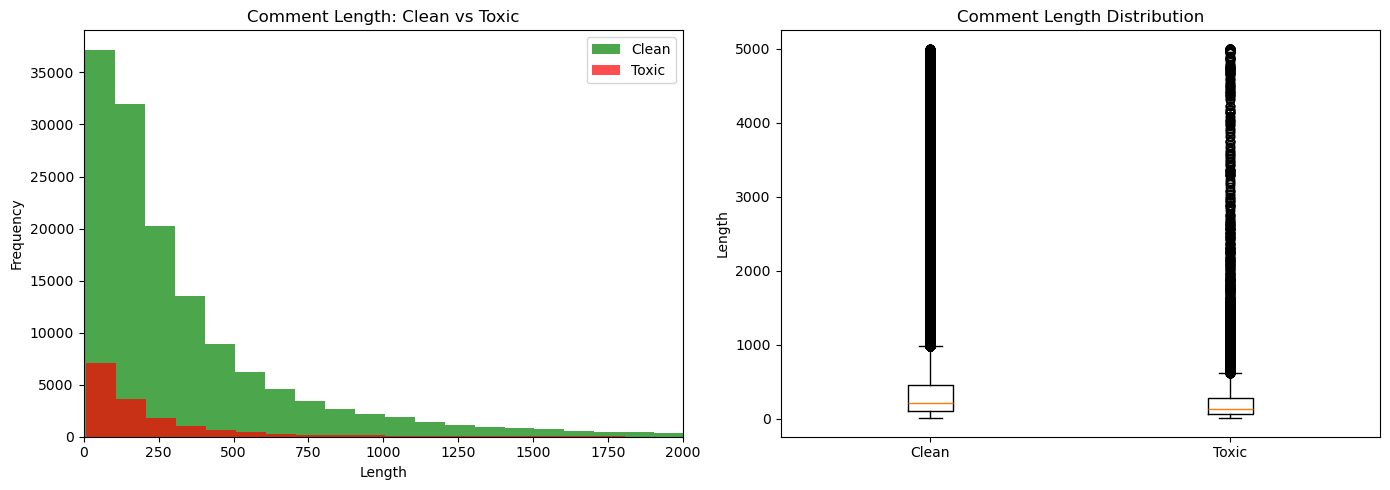

In [13]:
df['comment_length'] = df['comment_text'].apply(len)

print(f"Average comment length : {df['comment_length'].mean():.0f} chars")
print(f"Toxic comment avg length : {df[df['is_toxic']==1]['comment_length'].mean():.0f} chars")
print(f"Clean comment avg length : {df[df['is_toxic']==0]['comment_length'].mean():.0f} chars")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['is_toxic']==0]['comment_length'], bins=50, color='green', alpha=0.7, label='Clean')
axes[0].hist(df[df['is_toxic']==1]['comment_length'], bins=50, color='red', alpha=0.7, label='Toxic')
axes[0].set_title("Comment Length: Clean vs Toxic")
axes[0].set_xlabel("Length")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].set_xlim(0, 2000)

axes[1].boxplot([df[df['is_toxic']==0]['comment_length'],
                 df[df['is_toxic']==1]['comment_length']],
                labels=['Clean', 'Toxic'])
axes[1].set_title("Comment Length Distribution")
axes[1].set_ylabel("Length")

plt.tight_layout()
plt.show()


## 4. Text Preprocessing


In [14]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)


True

In [15]:

stop_words = set(stopwords.words('english'))

# Preserve words critical for toxicity meaning
important_words = {
    'you', 'your', 'yours', 'yourself',
    'he', 'she', 'they', 'them', 'him', 'her',
    'not', 'no', 'never',
    'will', 'shall', 'must', 'should'
}
stop_words = stop_words - important_words

l = WordNetLemmatizer()

def text_preprocess(text):
    text = text.strip()
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'[^a-zA-Z\s!?]', '', text)           # keep !? for intensity
    text = emoji.replace_emoji(text, replace='')          # remove emojis
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [l.lemmatize(w) for w in tokens]
    return ' '.join(tokens)


In [16]:
df['clean_comment'] = df['comment_text'].apply(text_preprocess)

#  check
print("Before:", df['comment_text'].iloc[1])
print("\nAfter :", df['clean_comment'].iloc[1])

Before: D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)

After : daww ! he match background colour im seemingly stuck thanks talk january utc


## 5. Train-Test Split

In [18]:
X = df['clean_comment']
y = df[label_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train_binary = (y_train.sum(axis=1) > 0).astype(int)
y_test_binary  = (y_test.sum(axis=1) > 0).astype(int)

print(f"Train size: {X_train.shape[0]:,}")
print(f"Test size : {X_test.shape[0]:,}")
print(f"\nBinary label distribution in train:")
print(y_train_binary.value_counts())

Train size: 127,656
Test size : 31,915

Binary label distribution in train:
0    114675
1     12981
Name: count, dtype: int64


## 6. TF-IDF Vectorization


In [19]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test) : {X_test_tfidf.shape}")


TF-IDF matrix shape (train): (127656, 10000)
TF-IDF matrix shape (test) : (31915, 10000)


## 7. Handling Class Imbalance — SMOTE


In [20]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train_binary)

print("Before SMOTE:")
print(y_train_binary.value_counts().to_string())
print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts().to_string())


Before SMOTE:
0    114675
1     12981

After SMOTE:
1    114675
0    114675


## 8. Stage 1 — Binary Classification (Toxic vs Clean)

### Model Comparison: Logistic Regression vs Random Forest


In [24]:
# Logistic Regression
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_smote, y_train_smote)

y_prob_lr = model_lr.predict_proba(X_test_tfidf)[:, 1]
y_pred_lr = (y_prob_lr > 0.5).astype(int)

# Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced', n_jobs=-1)
model_rf.fit(X_train_smote, y_train_smote)

y_prob_rf = model_rf.predict_proba(X_test_tfidf)[:, 1]
y_pred_rf = (y_prob_rf > 0.5).astype(int)


In [25]:
from sklearn.metrics import roc_auc_score, f1_score

results = {
    'Logistic Regression': {
        'F1'     : f1_score(y_test_binary, y_pred_lr),
        'ROC-AUC': roc_auc_score(y_test_binary, y_prob_lr)
    },
    'Random Forest': {
        'F1'     : f1_score(y_test_binary, y_pred_rf),
        'ROC-AUC': roc_auc_score(y_test_binary, y_prob_rf)
    }
}

print("Stage 1 — Model Comparison")
print("-" * 40)
for model, metrics in results.items():
    print(f"{model}")
    print(f"  F1 Score : {metrics['F1']:.4f}")
    print(f"  ROC-AUC  : {metrics['ROC-AUC']:.4f}")

Stage 1 — Model Comparison
----------------------------------------
Logistic Regression
  F1 Score : 0.6555
  ROC-AUC  : 0.9490
Random Forest
  F1 Score : 0.6846
  ROC-AUC  : 0.9402


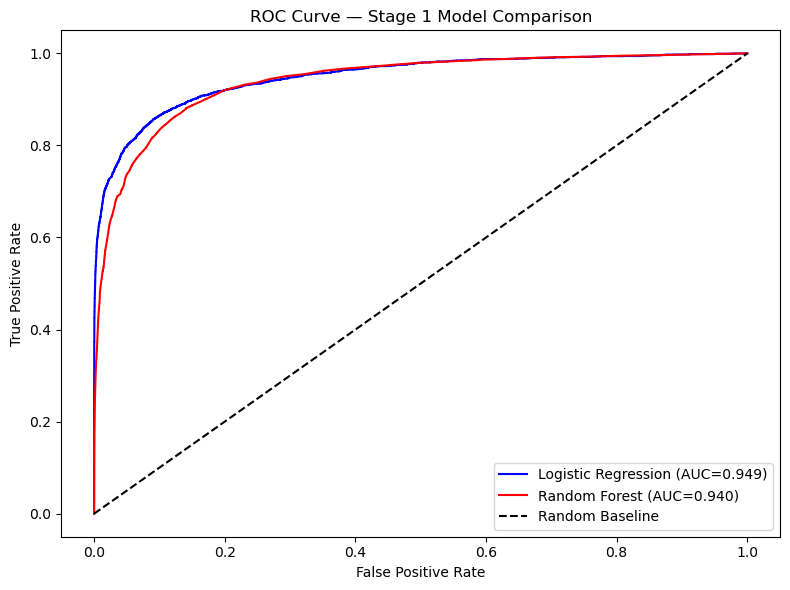

In [26]:
# ROC Curve comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test_binary, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test_binary, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_test_binary, y_prob_lr):.3f})", color='blue')
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test_binary, y_prob_rf):.3f})", color='red')
plt.plot([0,1],[0,1], 'k--', label='Random Baseline')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Stage 1 Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()


### Threshold Tuning


In [27]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

from sklearn.metrics import precision_score, recall_score

for t in thresholds:
    preds = (y_prob_lr > t).astype(int)
    p = precision_score(y_test_binary, preds)
    r = recall_score(y_test_binary, preds)
    f = f1_score(y_test_binary, preds)
    print(f"{t:<12} {p:<12.4f} {r:<12.4f} {f:<12.4f}")



Threshold    Precision    Recall       F1          
------------------------------------------------
0.3          0.3954       0.9020       0.5498      
0.35         0.4293       0.8887       0.5790      
0.4          0.4641       0.8758       0.6067      
0.45         0.4999       0.8625       0.6330      
0.5          0.5351       0.8459       0.6555      


Final Stage 1 Evaluation (threshold=0.4)
              precision    recall  f1-score   support

       Clean       0.98      0.89      0.93     28671
       Toxic       0.46      0.88      0.61      3244

    accuracy                           0.88     31915
   macro avg       0.72      0.88      0.77     31915
weighted avg       0.93      0.88      0.90     31915



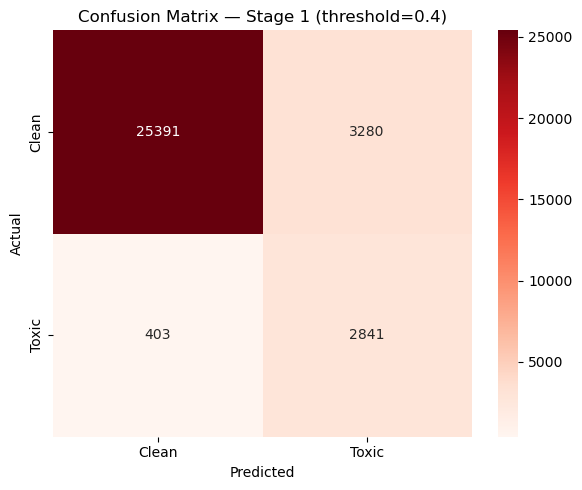

In [28]:
# Final Stage 1 model with chosen threshold
THRESHOLD = 0.4
y_pred_final = (y_prob_lr > THRESHOLD).astype(int)

print("Final Stage 1 Evaluation (threshold=0.4)")
print("=" * 50)
print(classification_report(y_test_binary, y_pred_final, target_names=['Clean', 'Toxic']))

cm = confusion_matrix(y_test_binary, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Clean', 'Toxic'],
            yticklabels=['Clean', 'Toxic'])
plt.title("Confusion Matrix — Stage 1 (threshold=0.4)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## 9. Stage 2 — Multi-Label Classification (Toxicity Type)


In [29]:
lr_multi = OneVsRestClassifier(
    LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
)
lr_multi.fit(X_train_tfidf, y_train)

y_pred_multi = lr_multi.predict(X_test_tfidf)

print("Stage 2 — Multi-Label Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_multi, target_names=label_cols))



Stage 2 — Multi-Label Classification Report
               precision    recall  f1-score   support

        toxic       0.61      0.87      0.71      3056
 severe_toxic       0.25      0.85      0.38       321
      obscene       0.63      0.88      0.74      1715
       threat       0.16      0.77      0.27        74
       insult       0.52      0.89      0.65      1614
identity_hate       0.20      0.77      0.31       294

    micro avg       0.51      0.87      0.64      7074
    macro avg       0.39      0.84      0.51      7074
 weighted avg       0.55      0.87      0.67      7074
  samples avg       0.06      0.08      0.07      7074



## 10. Save Models

In [30]:
joblib.dump(tfidf, 'tfidf.pkl')
joblib.dump(model_lr, 'binary_model.pkl')
joblib.dump(lr_multi, 'multilabel_model.pkl')



['multilabel_model.pkl']